In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/retail_price_feature_engineered.csv")

## Dataset Overview
Inspect the dataset before preparing it for machine learning.

In [3]:
df.shape

(676, 36)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

## Feature Selection

Separate the independent variables (features) from the dependent variable (target).

Target Variable:
- qty (Quantity Sold)

Features:
- Product information
- Pricing
- Competitor prices
- Customer information
- Engineered features

In [5]:
X = df.drop(columns=["qty"])

y = df["qty"]

## Data Preprocessing

Before training machine learning models, the dataset must be prepared by removing unnecessary columns and converting categorical variables into a numerical format.

### Preprocessing Steps
- Remove identifier columns.
- Remove redundant columns.
- Encode categorical variables.
- Separate features and target variable.

In [6]:
# Drop identifier column
df = df.drop(columns=["product_id"])

# Drop month_year because month and year already exist
df = df.drop(columns=["month_year"])

# One-Hot Encode categorical column
df = pd.get_dummies(df,
                    columns=["product_category_name"],
                    drop_first=True)

## Feature Selection

The dataset is divided into:

- Features (X): Independent variables used for prediction.
- Target (y): Quantity Sold (`qty`).

In [7]:
X = df.drop(columns=["qty"])

y = df["qty"]

## Train-Test Split

The dataset is split into training and testing sets.

- Training Set (80%) → Used to train the models.
- Testing Set (20%) → Used to evaluate model performance.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(540, 40)
(136, 40)


## Feature Scaling

Numerical features are standardized to ensure they have a similar scale. This helps algorithms that are sensitive to feature magnitudes.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Linear Regression

Linear Regression predicts the quantity sold based on a linear relationship between the features and the target variable.

In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

## Model Evaluation

Evaluate the model using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 :", lr_r2)

Linear Regression
MAE : 5.009428305386268
RMSE: 6.877254965778608
R2 : 0.8255340581193938


In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 :", dt_r2)

Decision Tree
MAE : 2.323529411764706
RMSE: 4.225274094833445
R2 : 0.9341447834339253


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 :", rf_r2)

Random Forest
MAE : 1.5402941176470588
RMSE: 4.699566312907156
R2 : 0.9185303271481055


## Model Comparison

Compare the performance of all machine learning models to identify the most accurate model for demand prediction.

In [14]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,Decision Tree,2.323529,4.225274,0.934145
2,Random Forest,1.540294,4.699566,0.918530
0,Linear Regression,5.009428,6.877255,0.825534


## Model Comparison

Three regression models were trained and evaluated using MAE, RMSE, and R² Score.

### Results

- **Decision Tree** achieved the highest R² Score (0.934) and the lowest RMSE, indicating the best overall predictive performance on this dataset.
- **Random Forest** produced the lowest MAE, showing strong prediction accuracy with a slightly higher RMSE.
- **Linear Regression** performed the weakest, suggesting that the relationship between features and quantity sold is not purely linear.

Based on these evaluation metrics, the **Decision Tree Regressor** was selected as the final model for demand prediction.

## Feature Importance

Feature importance identifies the variables that have the greatest influence on predicting product demand.

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
26,revenue,0.336554
0,total_price,0.310538
2,unit_price,0.172029
25,lag_price,0.071206
28,price_difference,0.014760
23,ps3,0.010577
14,s,0.008666
19,comp_2,0.008308
1,freight_price,0.008005
21,fp2,0.005860


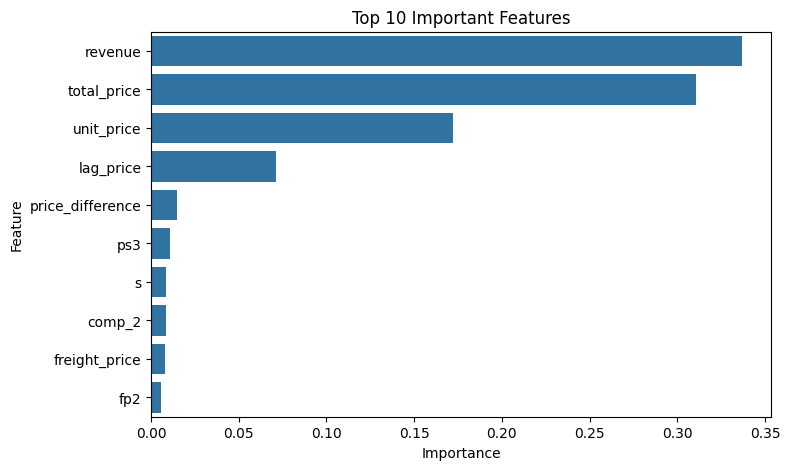

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

### Insights

- The feature importance chart highlights the variables that have the greatest influence on predicting product demand.
- Features with higher importance scores contribute more to the model's decision-making process.
- These insights can help businesses focus on the factors that most strongly affect sales and pricing strategies.